# Part C: PPO Training
This notebook trains, evaluates, compares, plots, and saves a single-agent PPO hospital-flow model.

## Install Requirements
This cell installs `requirements.txt` when present, otherwise it installs the minimum packages.

In [1]:
import os
import sys
import subprocess

def install_requirements():
    if os.path.exists("requirements.txt"):
        print("Installing dependencies from requirements.txt...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-r", "requirements.txt"
        ])
    else:
        print("requirements.txt not found. Installing minimum required packages...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install",
            "stable-baselines3",
            "gymnasium",
            "numpy",
            "pandas",
            "matplotlib",
            "torch"
        ])

install_requirements()

Installing dependencies from requirements.txt...


## Import Compatibility Guard
This avoids local TensorBoard, TensorFlow, protobuf, and NumPy alias issues before Stable-Baselines3 loads.

In [2]:
import os
import sys
import types
import numpy as np

os.environ.setdefault("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", "python")
os.environ.setdefault("TENSORBOARD_NO_TENSORFLOW", "1")
sys.modules.setdefault("tensorboard.compat.notf", types.ModuleType("tensorboard.compat.notf"))
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

## Imports
These libraries support PPO training, evaluation, plotting, and saved tabular outputs.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy

## CUDA / Device Check
The model uses CUDA when available and falls back to CPU without crashing.

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Selected device: {DEVICE}")

if DEVICE == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available. Training will run on CPU.")

Selected device: cuda
GPU name: NVIDIA GeForce RTX 3060 Laptop GPU


## Environment Loading or Definition
No standalone Python module was found, so `HospitalPPOEnv` is copied from the existing environment notebook.

## Environment Support Imports
These imports support the copied environment and Gymnasium compatibility.

In [5]:
from collections import deque
from dataclasses import dataclass
from typing import Any, Deque, Dict, Iterable, List, Optional, Tuple

import gymnasium as gym
from gymnasium import spaces

## Environment Constants
These constants define staff schedules, patient types, actions, and the patient record.

In [6]:
STAFF_SCHEDULE = {
    "day": {
        "nurses": 6,
        "doctors": 5,
        "physicians": 3,
        "radiologists": 2,
        "receptionists": 3,
        "administrators": 2,
        "paramedics": 4,
    },
    "evening": {
        "nurses": 4,
        "doctors": 3,
        "physicians": 2,
        "radiologists": 1,
        "receptionists": 2,
        "administrators": 1,
        "paramedics": 3,
    },
    "night": {
        "nurses": 2,
        "doctors": 1,
        "physicians": 1,
        "radiologists": 1,
        "receptionists": 1,
        "administrators": 1,
        "paramedics": 2,
    },
}

PATIENT_TYPES = {
    0: "emergency",
    1: "urgent",
    2: "elective_minor",
}

PATIENT_STAGES = {
    0: "arrival",
    1: "registration",
    2: "assessment",
    3: "triage",
    4: "imaging_tests",
    5: "treatment",
    6: "resus",
    7: "major",
    8: "minor",
    9: "general_admission",
    10: "icu_admission",
    11: "discharge",
    12: "delay_wait",
}

ACTION_MEANINGS = {
    0: "do_nothing",
    1: "register_patient",
    2: "move_to_assessment",
    3: "send_to_minor",
    4: "send_to_major",
    5: "send_to_resus",
    6: "request_imaging",
    7: "process_imaging",
    8: "treat_patient",
    9: "admit_general",
    10: "admit_icu",
    11: "discharge_patient",
    12: "delay_patient",
    13: "preserve_icu_capacity",
    14: "prioritise_emergency_flow",
}

SHIFT_ENCODING = {
    "day": 0,
    "evening": 1,
    "night": 2,
}

PATIENT_TYPE_PROBABILITIES = np.asarray([0.2, 0.3, 0.5], dtype=np.float64)

@dataclass(eq=False)
class Patient:
    patient_type: int
    stage: int = 0
    waiting_time: int = 0
    needs_imaging: bool = False
    area: Optional[str] = None


## Stable-Baselines3 Compatibility Fix
The copied class subclasses `gym.Env`; the hospital-flow logic is otherwise preserved.

## HospitalPPOEnv Class
This is the single-agent hospital operations environment used by PPO.

In [7]:
class HospitalPPOEnv(gym.Env):
    """Single-agent operational hospital-flow environment for later PPO training.

    This is not a grid-world. It models queues, stages, staff capacity, beds,
    admissions, discharges, waiting time, and congestion.
    """

    metadata = {"name": "HospitalPPOEnv"}

    def __init__(
        self,
        registration_queue_max: int = 20,
        assessment_queue_max: int = 20,
        resus_max: int = 3,
        major_max: int = 8,
        minor_max: int = 10,
        general_max: int = 20,
        icu_max: int = 6,
        max_steps: int = 500,
        arrival_probability: float = 0.65,
        patient_type_probabilities: np.ndarray = PATIENT_TYPE_PROBABILITIES,
        staff_schedule: Optional[Dict[str, Dict[str, int]]] = None,
    ) -> None:
        self.registration_queue_max = int(registration_queue_max)
        self.assessment_queue_max = int(assessment_queue_max)
        self.resus_max = int(resus_max)
        self.major_max = int(major_max)
        self.minor_max = int(minor_max)
        self.general_max = int(general_max)
        self.icu_max = int(icu_max)
        self.max_steps = int(max_steps)
        self.arrival_probability = float(arrival_probability)
        self.patient_type_probabilities = np.asarray(patient_type_probabilities, dtype=np.float64)
        self.patient_type_probabilities /= self.patient_type_probabilities.sum()
        self.staff_schedule = staff_schedule or STAFF_SCHEDULE

        self.resus_release_probability = 0.25
        self.major_release_probability = 0.30
        self.minor_release_probability = 0.50
        self.general_discharge_probability = 0.35
        self.icu_discharge_probability = 0.20

        self.action_space = spaces.Discrete(15)
        self.observation_space = spaces.Box(
            low=np.zeros(18, dtype=np.float32),
            high=np.asarray(
                [
                    self.registration_queue_max,
                    self.assessment_queue_max,
                    self.resus_max,
                    self.major_max,
                    self.minor_max,
                    self.general_max,
                    self.icu_max,
                    2,
                    12,
                    self.max_steps,
                    max(v["nurses"] for v in self.staff_schedule.values()),
                    max(v["doctors"] for v in self.staff_schedule.values()),
                    max(v["physicians"] for v in self.staff_schedule.values()),
                    max(v["radiologists"] for v in self.staff_schedule.values()),
                    max(v["receptionists"] for v in self.staff_schedule.values()),
                    max(v["administrators"] for v in self.staff_schedule.values()),
                    max(v["paramedics"] for v in self.staff_schedule.values()),
                    2,
                ],
                dtype=np.float32,
            ),
            dtype=np.float32,
        )

        self._np_random = np.random.default_rng()
        self._arrival_queue: Deque[Patient] = deque()
        self._registration_patients: Deque[Patient] = deque()
        self._assessment_patients: Deque[Patient] = deque()
        self._imaging_patients: Deque[Patient] = deque()
        self._treatment_patients: Deque[Patient] = deque()
        self._admission_patients: Deque[Patient] = deque()
        self._resus_patients: Deque[Patient] = deque()
        self._major_patients: Deque[Patient] = deque()
        self._minor_patients: Deque[Patient] = deque()
        self._general_patients: Deque[Patient] = deque()
        self._icu_patients: Deque[Patient] = deque()

        self._reset_public_state()

    def reset(self, seed: Optional[int] = None, options: Optional[Dict[str, Any]] = None) -> Tuple[np.ndarray, Dict[str, Any]]:
        if seed is not None:
            self._np_random = np.random.default_rng(seed)

        options = options or {}
        self.timestep = 0
        self._preserve_icu_mode = False

        for queue in self._all_queues():
            queue.clear()

        self.resus_free = self.resus_max
        self.major_free = self.major_max
        self.minor_free = self.minor_max
        self.general_free = self.general_max
        self.icu_free = self.icu_max
        self.shift = self._shift_from_timestep(self.timestep)
        self._apply_shift_staffing()

        initial_patients = int(options.get("initial_patients", 1))
        for _ in range(max(initial_patients, 0)):
            self._arrival_queue.append(self._new_patient())

        self._sync_public_state()
        return self._get_observation(), self._get_info(events=["reset"])

    def step(self, action: int) -> Tuple[np.ndarray, float, bool, bool, Dict[str, Any]]:
        action = int(np.clip(action, 0, self.action_space.n - 1))
        self.timestep += 1
        self.shift = self._shift_from_timestep(self.timestep)
        self._apply_shift_staffing()

        reward_components = []
        events = []

        release_reward = self._release_capacity(events)
        reward_components.append(("release_throughput", release_reward))

        if self._np_random.random() < self.arrival_probability:
            self._arrival_queue.append(self._new_patient())
            events.append("new_patient_arrived")

        action_reward = self._apply_action(action, events)
        reward_components.append(("action_reward", action_reward))

        waiting_penalty = self._update_waiting_times()
        reward_components.append(("waiting_penalty", -waiting_penalty))

        congestion_penalty = self._queue_congestion_penalty()
        reward_components.append(("queue_congestion_penalty", -congestion_penalty))

        icu_reward = self._icu_preservation_reward()
        reward_components.append(("icu_preservation_reward", icu_reward))

        self._sync_public_state()
        reward = float(sum(value for _, value in reward_components))
        terminated = False
        truncated = self.timestep >= self.max_steps
        info = self._get_info(
            action=action,
            action_meaning=ACTION_MEANINGS[action],
            events=events,
            reward_components=dict(reward_components),
        )
        return self._get_observation(), reward, terminated, truncated, info

    def _apply_action(self, action: int, events: List[str]) -> float:
        if action == 0:
            events.append("do_nothing")
            return -0.1 if self._has_waiting_patients() else 0.0
        if action == 1:
            return self._register_patient(events)
        if action == 2:
            return self._move_to_assessment(events)
        if action == 3:
            return self._send_to_area("minor", events)
        if action == 4:
            return self._send_to_area("major", events)
        if action == 5:
            return self._send_to_area("resus", events)
        if action == 6:
            return self._request_imaging(events)
        if action == 7:
            return self._process_imaging(events)
        if action == 8:
            return self._treat_patient(events)
        if action == 9:
            return self._admit_general(events)
        if action == 10:
            return self._admit_icu(events)
        if action == 11:
            return self._discharge_patient(events)
        if action == 12:
            return self._delay_patient(events)
        if action == 13:
            return self._preserve_icu_capacity(events)
        if action == 14:
            return self._prioritise_emergency_flow(events)
        return 0.0

    def _register_patient(self, events: List[str]) -> float:
        if not self._arrival_queue or len(self._registration_patients) >= self.registration_queue_max:
            events.append("registration_blocked")
            return -1.0
        if self.receptionists_available <= 0:
            events.append("no_receptionist_available")
            return -1.0
        patient = self._pop_priority(self._arrival_queue)
        patient.stage = 1
        self._registration_patients.append(patient)
        events.append("patient_registered")
        return 1.0 if patient.patient_type != 0 else 2.0

    def _move_to_assessment(self, events: List[str]) -> float:
        if not self._registration_patients or len(self._assessment_patients) >= self.assessment_queue_max:
            events.append("assessment_move_blocked")
            return -1.0
        patient = self._pop_priority(self._registration_patients)
        patient.stage = 2
        self._assessment_patients.append(patient)
        events.append("patient_moved_to_assessment")
        return 1.0 if patient.patient_type != 0 else 2.0

    def _send_to_area(self, area: str, events: List[str]) -> float:
        if not self._assessment_patients:
            events.append(f"send_to_{area}_blocked_no_patient")
            return -1.0
        if self.nurses_available <= 0:
            events.append("no_nurse_available")
            return -1.0
        if getattr(self, f"{area}_free") <= 0:
            events.append(f"send_to_{area}_blocked_no_capacity")
            patient = self._peek_priority(self._assessment_patients)
            if patient and patient.patient_type == 0 and area in {"resus", "major"}:
                events.append("emergency_rejection")
                return -8.0
            return -2.0

        patient = self._pop_priority(self._assessment_patients)
        patient.stage = {"resus": 6, "major": 7, "minor": 8}[area]
        patient.area = area
        getattr(self, f"_{area}_patients").append(patient)
        self._treatment_patients.append(patient)
        setattr(self, f"{area}_free", getattr(self, f"{area}_free") - 1)
        events.append(f"patient_sent_to_{area}")

        if patient.patient_type == 0 and area == "resus":
            return 10.0
        if patient.patient_type == 1 and area == "major":
            return 6.0
        if patient.patient_type == 2 and area == "minor":
            return 3.0
        if patient.patient_type != 0 and area == "resus":
            return -5.0
        if patient.patient_type == 0 and area == "minor":
            return -8.0
        return 0.5

    def _request_imaging(self, events: List[str]) -> float:
        patient = self._pop_priority(self._treatment_patients)
        if patient is None:
            events.append("imaging_request_blocked")
            return -1.0
        patient.stage = 4
        patient.needs_imaging = True
        self._imaging_patients.append(patient)
        events.append("imaging_requested")
        return 1.0 if patient.patient_type in {0, 1} else 0.5

    def _process_imaging(self, events: List[str]) -> float:
        if not self._imaging_patients:
            events.append("process_imaging_blocked")
            return -1.0
        if self.radiologists_available <= 0:
            events.append("no_radiologist_available")
            return -1.0
        patient = self._pop_priority(self._imaging_patients)
        patient.needs_imaging = False
        patient.stage = 5
        self._treatment_patients.append(patient)
        events.append("imaging_processed")
        return 1.5

    def _treat_patient(self, events: List[str]) -> float:
        patient = self._pop_priority(self._treatment_patients)
        if patient is None:
            events.append("treatment_blocked")
            return -1.0
        if self.doctors_available <= 0:
            self._treatment_patients.appendleft(patient)
            events.append("no_doctor_available")
            return -1.0
        patient.stage = 5
        events.append("patient_treated")
        if patient.patient_type == 2:
            patient.stage = 11
            self._release_area(patient)
            events.append("minor_patient_ready_for_discharge")
            return 3.0
        self._admission_patients.append(patient)
        return 2.0

    def _admit_general(self, events: List[str]) -> float:
        patient = self._pop_priority(self._admission_patients)
        if patient is None:
            events.append("general_admission_blocked_no_patient")
            return -1.0
        if self.physicians_available <= 0 or self.general_free <= 0:
            self._admission_patients.appendleft(patient)
            events.append("general_admission_blocked")
            return -3.0
        patient.stage = 9
        self._release_area(patient)
        patient.area = "general"
        self._general_patients.append(patient)
        self.general_free -= 1
        events.append("patient_admitted_general")
        if patient.patient_type == 1:
            return 6.0
        if patient.patient_type == 2:
            return 3.0
        return 2.0

    def _admit_icu(self, events: List[str]) -> float:
        patient = self._pop_priority(self._admission_patients)
        if patient is None:
            events.append("icu_admission_blocked_no_patient")
            return -1.0
        if self.physicians_available <= 0 or self.icu_free <= 0:
            self._admission_patients.appendleft(patient)
            events.append("icu_admission_blocked")
            return -8.0 if patient.patient_type == 0 else -3.0
        patient.stage = 10
        self._release_area(patient)
        patient.area = "icu"
        self._icu_patients.append(patient)
        self.icu_free -= 1
        events.append("patient_admitted_icu")
        if patient.patient_type == 0:
            return 10.0
        return -5.0

    def _discharge_patient(self, events: List[str]) -> float:
        patient = self._pop_priority(self._admission_patients)
        if patient is None:
            patient = self._pop_priority(self._treatment_patients)
        if patient is None:
            patient = self._find_low_acuity_area_patient()
        if patient is None:
            events.append("discharge_blocked_no_patient")
            return -1.0
        patient.stage = 11
        self._release_area(patient)
        self._remove_from_all_active_queues(patient)
        events.append("patient_discharged")
        if patient.patient_type == 2:
            return 3.0 + 2.0
        return -6.0

    def _delay_patient(self, events: List[str]) -> float:
        patient = self._focus_patient()
        if patient is None:
            events.append("delay_no_patient")
            return -0.2
        patient.stage = 12
        patient.waiting_time += 1
        events.append("patient_delayed")
        if patient.patient_type == 0 and patient.waiting_time >= 4:
            events.append("emergency_rejection")
            return -10.0
        return -1.0

    def _preserve_icu_capacity(self, events: List[str]) -> float:
        self._preserve_icu_mode = True
        events.append("icu_capacity_preserved")
        if not self._has_emergency_waiting() and self.icu_free >= 1:
            return 1.0
        if self._has_emergency_waiting() and (self.icu_free > 0 or self.resus_free > 0):
            return -8.0
        return 0.0

    def _prioritise_emergency_flow(self, events: List[str]) -> float:
        for queue in self._front_door_queues():
            ordered = sorted(queue, key=lambda p: (p.patient_type, -p.waiting_time))
            queue.clear()
            queue.extend(ordered)
        events.append("emergency_flow_prioritised")
        return 2.0 if self._has_emergency_waiting() else 0.2

    def _release_capacity(self, events: List[str]) -> float:
        reward = 0.0
        reward += 0.5 * self._release_from_queue(self._resus_patients, "resus", self.resus_max, self.resus_release_probability, events)
        reward += 0.4 * self._release_from_queue(self._major_patients, "major", self.major_max, self.major_release_probability, events)
        reward += 0.3 * self._release_from_queue(self._minor_patients, "minor", self.minor_max, self.minor_release_probability, events)
        reward += 0.4 * self._release_from_queue(self._general_patients, "general", self.general_max, self.general_discharge_probability, events)
        reward += 0.5 * self._release_from_queue(self._icu_patients, "icu", self.icu_max, self.icu_discharge_probability, events)
        return reward

    def _release_from_queue(self, queue: Deque[Patient], area: str, capacity: int, probability: float, events: List[str]) -> int:
        kept = deque()
        released = 0
        while queue:
            patient = queue.popleft()
            if self._np_random.random() < probability:
                patient.stage = 11
                patient.area = None
                self._remove_from_all_active_queues(patient)
                released += 1
            else:
                kept.append(patient)
        queue.extend(kept)
        setattr(self, f"{area}_free", capacity - len(queue))
        if released:
            events.append(f"{area}_released_{released}")
        return released

    def _update_waiting_times(self) -> float:
        penalty = 0.0
        for queue in self._waiting_queues():
            for patient in queue:
                patient.waiting_time += 1
                penalty += 1.0
                if patient.patient_type == 0 and patient.waiting_time >= 4:
                    penalty += 10.0
        return penalty

    def _queue_congestion_penalty(self) -> float:
        congested = (
            len(self._registration_patients) >= 0.8 * self.registration_queue_max
            or len(self._assessment_patients) >= 0.8 * self.assessment_queue_max
        )
        return 3.0 if congested else 0.0

    def _icu_preservation_reward(self) -> float:
        if not self._has_emergency_waiting() and self.icu_free >= 1:
            return 1.0
        return 0.0

    def _new_patient(self) -> Patient:
        patient_type = int(self._np_random.choice([0, 1, 2], p=self.patient_type_probabilities))
        return Patient(patient_type=patient_type, stage=0)

    def _shift_from_timestep(self, timestep: int) -> str:
        hour = timestep % 24
        if 8 <= hour <= 15:
            return "day"
        if 16 <= hour <= 23:
            return "evening"
        return "night"

    def _apply_shift_staffing(self) -> None:
        staff = self.staff_schedule[self.shift]
        self.nurses_available = staff["nurses"]
        self.doctors_available = staff["doctors"]
        self.physicians_available = staff["physicians"]
        self.radiologists_available = staff["radiologists"]
        self.receptionists_available = staff["receptionists"]
        self.administrators_available = staff["administrators"]
        self.paramedics_available = staff["paramedics"]

    def _reset_public_state(self) -> None:
        self.timestep = 0
        self.shift = "night"
        self.registration_queue = 0
        self.assessment_queue = 0
        self.resus_free = self.resus_max
        self.major_free = self.major_max
        self.minor_free = self.minor_max
        self.general_free = self.general_max
        self.icu_free = self.icu_max
        self.patient_type = 2
        self.patient_stage = 0
        self.waiting_time = 0
        self._preserve_icu_mode = False
        self._apply_shift_staffing()

    def _sync_public_state(self) -> None:
        self.registration_queue = len(self._registration_patients)
        self.assessment_queue = len(self._assessment_patients)
        patient = self._focus_patient()
        self.patient_type = patient.patient_type if patient else 2
        self.patient_stage = patient.stage if patient else 11
        self.waiting_time = patient.waiting_time if patient else 0

    def _get_observation(self) -> np.ndarray:
        return np.asarray(
            [
                self.registration_queue,
                self.assessment_queue,
                self.resus_free,
                self.major_free,
                self.minor_free,
                self.general_free,
                self.icu_free,
                self.patient_type,
                self.patient_stage,
                self.waiting_time,
                self.nurses_available,
                self.doctors_available,
                self.physicians_available,
                self.radiologists_available,
                self.receptionists_available,
                self.administrators_available,
                self.paramedics_available,
                SHIFT_ENCODING[self.shift],
            ],
            dtype=np.float32,
        )

    def _get_info(self, action: Optional[int] = None, action_meaning: Optional[str] = None, events: Optional[List[str]] = None, reward_components: Optional[Dict[str, float]] = None) -> Dict[str, Any]:
        return {
            "timestep": self.timestep,
            "shift": self.shift,
            "action": action,
            "action_meaning": action_meaning,
            "events": events or [],
            "reward_components": reward_components or {},
            "emergency_rejection": int("emergency_rejection" in (events or [])),
            "icu_utilisation": 1.0 - (self.icu_free / max(self.icu_max, 1)),
            "patient_type_meaning": PATIENT_TYPES[self.patient_type],
            "patient_stage_meaning": PATIENT_STAGES[self.patient_stage],
            "queue_lengths": {
                "arrival": len(self._arrival_queue),
                "registration": len(self._registration_patients),
                "assessment": len(self._assessment_patients),
                "imaging": len(self._imaging_patients),
                "treatment": len(self._treatment_patients),
                "admission": len(self._admission_patients),
            },
            "free_capacity": {
                "resus": self.resus_free,
                "major": self.major_free,
                "minor": self.minor_free,
                "general": self.general_free,
                "icu": self.icu_free,
            },
        }

    def _pop_priority(self, queue: Deque[Patient]) -> Optional[Patient]:
        if not queue:
            return None
        best = min(queue, key=lambda p: (p.patient_type, -p.waiting_time))
        queue.remove(best)
        return best

    def _peek_priority(self, queue: Deque[Patient]) -> Optional[Patient]:
        if not queue:
            return None
        return min(queue, key=lambda p: (p.patient_type, -p.waiting_time))

    def _focus_patient(self) -> Optional[Patient]:
        candidates = []
        for queue in self._waiting_queues():
            candidates.extend(list(queue))
        if not candidates:
            return None
        return min(candidates, key=lambda p: (p.patient_type, -p.waiting_time))

    def _has_waiting_patients(self) -> bool:
        return any(len(queue) > 0 for queue in self._waiting_queues())

    def _has_emergency_waiting(self) -> bool:
        return any(patient.patient_type == 0 for queue in self._waiting_queues() for patient in queue)

    def _find_low_acuity_area_patient(self) -> Optional[Patient]:
        for queue in [self._minor_patients, self._major_patients, self._general_patients]:
            for patient in list(queue):
                if patient.patient_type == 2:
                    queue.remove(patient)
                    return patient
        return None

    def _release_area(self, patient: Patient) -> None:
        if patient.area not in {"resus", "major", "minor", "general", "icu"}:
            return
        area = patient.area
        queue = getattr(self, f"_{area}_patients")
        try:
            queue.remove(patient)
        except ValueError:
            pass
        free_attr = f"{area}_free"
        max_attr = f"{area}_max"
        setattr(self, free_attr, min(getattr(self, free_attr) + 1, getattr(self, max_attr)))
        patient.area = None

    def _remove_from_all_active_queues(self, patient: Patient) -> None:
        for queue in self._waiting_queues() + [
            self._resus_patients,
            self._major_patients,
            self._minor_patients,
            self._general_patients,
            self._icu_patients,
        ]:
            try:
                queue.remove(patient)
            except ValueError:
                pass

    def _front_door_queues(self) -> List[Deque[Patient]]:
        return [self._arrival_queue, self._registration_patients, self._assessment_patients]

    def _waiting_queues(self) -> List[Deque[Patient]]:
        return [
            self._arrival_queue,
            self._registration_patients,
            self._assessment_patients,
            self._imaging_patients,
            self._treatment_patients,
            self._admission_patients,
        ]

    def _all_queues(self) -> List[Deque[Patient]]:
        return self._waiting_queues() + [
            self._resus_patients,
            self._major_patients,
            self._minor_patients,
            self._general_patients,
            self._icu_patients,
        ]


## Environment Smoke Test
This quick rollout checks reset and step outputs without training an agent.

In [8]:
env = HospitalPPOEnv(max_steps=10)
observation, info = env.reset(seed=42)

print("Initial observation:", observation)
print("Initial info:", info)

for step in range(10):
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    print(f"Step {step + 1}")
    print("  action:", action, ACTION_MEANINGS[action])
    print("  observation:", observation)
    print("  reward:", reward)
    print("  terminated:", terminated)
    print("  truncated:", truncated)
    print("  info:", info)
    if terminated or truncated:
        break


Initial observation: [ 0.  0.  3.  8. 10. 20.  6.  2.  0.  0.  2.  1.  1.  1.  1.  1.  2.  2.]
Initial info: {'timestep': 0, 'shift': 'night', 'action': None, 'action_meaning': None, 'events': ['reset'], 'reward_components': {}, 'emergency_rejection': 0, 'icu_utilisation': 0.0, 'patient_type_meaning': 'elective_minor', 'patient_stage_meaning': 'arrival', 'queue_lengths': {'arrival': 1, 'registration': 0, 'assessment': 0, 'imaging': 0, 'treatment': 0, 'admission': 0}, 'free_capacity': {'resus': 3, 'major': 8, 'minor': 10, 'general': 20, 'icu': 6}}
Step 1
  action: 11 discharge_patient
  observation: [ 0.  0.  3.  8. 10. 20.  6.  2.  0.  1.  2.  1.  1.  1.  1.  1.  2.  2.]
  reward: -2.0
  terminated: False
  truncated: False
  info: {'timestep': 1, 'shift': 'night', 'action': 11, 'action_meaning': 'discharge_patient', 'events': ['new_patient_arrived', 'discharge_blocked_no_patient'], 'reward_components': {'release_throughput': 0.0, 'action_reward': -1.0, 'waiting_penalty': -2.0, 'queue_

## Environment Compatibility Check
This verifies the environment against Stable-Baselines3 expectations before training.

In [9]:
env = HospitalPPOEnv()
check_env(env, warn=True)
print("Environment compatibility check complete.")

Environment compatibility check complete.


## Environment Factory Function
The factory wraps the environment with `Monitor` so PPO can record episode statistics.

In [10]:
def make_env(use_reward_shaping=True, reward_config=None, use_action_guardrail=True):
    env = HospitalPPOEnv()

    if use_action_guardrail:
        env = HospitalActionGuardrailWrapper(env)

    if use_reward_shaping:
        env = HospitalRewardShapingWrapper(env, reward_config=reward_config)

    env = Monitor(env)
    return env


## Action Labels
These labels make PPO diagnostics readable by mapping each discrete action to its hospital-flow meaning.

In [11]:
ACTION_MEANINGS = {
    0: "do_nothing",
    1: "register_patient",
    2: "move_to_assessment",
    3: "send_to_minor",
    4: "send_to_major",
    5: "send_to_resus",
    6: "request_imaging",
    7: "process_imaging",
    8: "treat_patient",
    9: "admit_general",
    10: "admit_icu",
    11: "discharge_patient",
    12: "delay_patient",
    13: "preserve_icu_capacity",
    14: "prioritise_emergency_flow",
}


## Reward Shaping Configuration
These values are applied by a wrapper during training only; the base environment reward remains unchanged.

In [12]:
REWARD_SHAPING_CONFIG = {
    "patient_registered": 1.0,
    "patient_moved_to_assessment": 1.0,
    "patient_sent_to_minor": 1.5,
    "patient_sent_to_major": 2.0,
    "patient_sent_to_resus": 4.0,
    "imaging_requested": 1.0,
    "imaging_processed": 2.0,
    "patient_treated": 3.0,
    "patient_admitted_general": 6.0,
    "patient_admitted_icu": 8.0,
    "patient_discharged": 6.0,
    "emergency_rejection": -20.0,
    "unsafe_discharge": -15.0,
    "patient_delayed": -1.0,
    "do_nothing": -0.2,
    "invalid_action": -1.0,
    "icu_preservation": 1.0,
    "unnecessary_icu": -8.0,
}


## Reward Sensitivity Settings
These pilot settings compare conservative, balanced, and emergency-focused shaping before long training.

In [13]:
REWARD_SENSITIVITY_CONFIGS = {
    "conservative": {
        "waiting_penalty_proxy": -0.02,
        "invalid_action": -0.5,
        "patient_discharged": 4.0,
        "emergency_rejection": -15.0,
    },
    "balanced": {
        "waiting_penalty_proxy": -0.05,
        "invalid_action": -1.0,
        "patient_discharged": 6.0,
        "emergency_rejection": -20.0,
    },
    "strict_emergency": {
        "waiting_penalty_proxy": -0.05,
        "invalid_action": -1.0,
        "patient_sent_to_resus": 6.0,
        "patient_admitted_icu": 10.0,
        "emergency_rejection": -30.0,
        "patient_delayed": -2.0,
    },
}


def build_reward_config(setting_name="balanced"):
    config = REWARD_SHAPING_CONFIG.copy()
    overrides = REWARD_SENSITIVITY_CONFIGS.get(setting_name, {})
    for key, value in overrides.items():
        if key != "waiting_penalty_proxy":
            config[key] = value
    return config


## Training-Time Reward Wrapper
The wrapper adds external shaping rewards from `info["events"]` without changing `HospitalPPOEnv`.

In [14]:
class HospitalRewardShapingWrapper(gym.Wrapper):
    """Apply transparent training-time reward shaping around HospitalPPOEnv."""

    def __init__(self, env, reward_config=None):
        super().__init__(env)
        self.reward_config = REWARD_SHAPING_CONFIG.copy()
        if reward_config is not None:
            self.reward_config.update(reward_config)

    def step(self, action):
        observation, reward, terminated, truncated, info = self.env.step(action)
        info = dict(info)
        events = list(info.get("events", []))

        base_reward = float(reward)
        shaping_reward = 0.0

        for event in events:
            shaping_reward += float(self.reward_config.get(event, 0.0))

        action_id = int(np.asarray(action).item())

        if action_id == 0:
            shaping_reward += float(self.reward_config.get("do_nothing", 0.0))

        if action_id == 12 and "patient_delayed" not in events:
            shaping_reward += float(self.reward_config.get("patient_delayed", 0.0))

        if info.get("emergency_rejection", 0) and "emergency_rejection" not in events:
            shaping_reward += float(self.reward_config.get("emergency_rejection", 0.0))

        if info.get("invalid_action", 0):
            shaping_reward += float(self.reward_config.get("invalid_action", 0.0))

        if action_id == 10 and info.get("patient_type_meaning") != "emergency":
            shaping_reward += float(self.reward_config.get("unnecessary_icu", -8.0))

        if action_id == 13:
            shaping_reward += float(self.reward_config.get("icu_preservation", 0.0))

        shaped_reward = base_reward + shaping_reward
        info["base_reward"] = base_reward
        info["reward_shaping"] = shaping_reward
        info["shaped_reward"] = shaped_reward

        return observation, shaped_reward, terminated, truncated, info


## Action Diagnostic Helpers
These functions show whether PPO is using useful flow actions or collapsing into repeated no-op/delay choices.

In [15]:
def action_counts_to_frame(action_counts):
    rows = []
    total = int(sum(action_counts.values()))

    for action_id in range(len(ACTION_MEANINGS)):
        count = int(action_counts.get(action_id, 0))
        rows.append({
            "action": action_id,
            "action_name": ACTION_MEANINGS[action_id],
            "count": count,
            "proportion": count / total if total else 0.0,
        })

    return pd.DataFrame(rows)


def most_common_action_label(action_counts):
    if not action_counts:
        return "none"

    action_id = max(action_counts, key=action_counts.get)
    return f"{action_id}: {ACTION_MEANINGS[action_id]}"


def print_most_common_actions(action_counts_df, top_n=5):
    top_actions = action_counts_df.sort_values("count", ascending=False).head(top_n)
    print("Most common PPO actions:")
    for _, row in top_actions.iterrows():
        print(f"  {int(row['action'])}: {row['action_name']} -> {int(row['count'])} selections")


def plot_action_frequencies(action_counts_df, title="PPO Action Frequencies"):
    labels = [f"{int(row.action)}\n{row.action_name}" for row in action_counts_df.itertuples()]

    plt.figure(figsize=(12, 4))
    plt.bar(labels, action_counts_df["count"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Action count")
    plt.title(title)
    plt.tight_layout()
    plt.show()


## Action Validity Guardrail
The latest PPO output repeatedly selected `move_to_assessment`, so this wrapper blocks impossible actions during training.

In [16]:
ACTION_GUARDRAIL_PENALTY = -0.5


def unwrap_hospital_env(env):
    while hasattr(env, "env"):
        env = env.env
    return env


def has_low_acuity_area_patient(env):
    return any(
        patient.patient_type == 2
        for queue in [env._minor_patients, env._major_patients, env._general_patients]
        for patient in queue
    )


def get_valid_actions_for_env(env):
    base_env = unwrap_hospital_env(env)
    valid_actions = {0, 13, 14}

    if base_env._has_waiting_patients():
        valid_actions.add(12)

    if base_env._arrival_queue and len(base_env._registration_patients) < base_env.registration_queue_max and base_env.receptionists_available > 0:
        valid_actions.add(1)

    if base_env._registration_patients and len(base_env._assessment_patients) < base_env.assessment_queue_max:
        valid_actions.add(2)

    if base_env._assessment_patients and base_env.nurses_available > 0:
        if base_env.minor_free > 0:
            valid_actions.add(3)
        if base_env.major_free > 0:
            valid_actions.add(4)
        if base_env.resus_free > 0:
            valid_actions.add(5)

    if base_env._treatment_patients:
        valid_actions.add(6)
        if base_env.doctors_available > 0:
            valid_actions.add(8)

    if base_env._imaging_patients and base_env.radiologists_available > 0:
        valid_actions.add(7)

    if base_env._admission_patients and base_env.physicians_available > 0:
        if base_env.general_free > 0:
            valid_actions.add(9)
        if base_env.icu_free > 0:
            valid_actions.add(10)

    if base_env._admission_patients or base_env._treatment_patients or has_low_acuity_area_patient(base_env):
        valid_actions.add(11)

    return sorted(valid_actions)


class HospitalActionGuardrailWrapper(gym.Wrapper):
    """Map impossible actions to do_nothing and expose action-validity diagnostics."""

    def __init__(self, env, invalid_action_penalty=ACTION_GUARDRAIL_PENALTY):
        super().__init__(env)
        self.invalid_action_penalty = float(invalid_action_penalty)

    def step(self, action):
        original_action = int(np.asarray(action).item())
        valid_actions = get_valid_actions_for_env(self.env)
        action_was_guarded = original_action not in valid_actions
        executed_action = 0 if action_was_guarded else original_action

        observation, reward, terminated, truncated, info = self.env.step(executed_action)
        info = dict(info)
        events = list(info.get("events", []))

        if action_was_guarded:
            reward = float(reward) + self.invalid_action_penalty
            events.append("action_guarded_invalid")

        info["events"] = events
        info["original_action"] = original_action
        info["original_action_meaning"] = ACTION_MEANINGS.get(original_action, "unknown")
        info["executed_action"] = executed_action
        info["executed_action_meaning"] = ACTION_MEANINGS.get(executed_action, "unknown")
        info["valid_actions"] = valid_actions
        info["invalid_action"] = int(action_was_guarded)
        info["action_was_guarded"] = int(action_was_guarded)

        return observation, float(reward), terminated, truncated, info


## Action Validity Diagnostics
These helpers report invalid-action rates so PPO can be checked for impossible-action loops after training.

In [17]:
def plot_invalid_action_rates(results_df, title="Invalid Action Rate by Episode"):
    if "invalid_action_rate" not in results_df.columns:
        print("No invalid_action_rate column found.")
        return

    plt.figure(figsize=(10, 4))
    plt.plot(results_df["episode"], results_df["invalid_action_rate"])
    plt.xlabel("Episode")
    plt.ylabel("Invalid action rate")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def summarise_action_validity(results_df):
    columns = [
        "invalid_actions",
        "guarded_actions",
        "invalid_action_rate",
        "successful_discharges",
        "general_admissions",
        "icu_admissions",
        "total_reward",
    ]
    available = [column for column in columns if column in results_df.columns]
    return results_df[available].mean(numeric_only=True)


## PPO Policy Equation
The policy is $\pi_\theta(a_t\mid s_t)$, written as ?_? for action probabilities.

## PPO Clipped Objective
PPO optimises $L^{CLIP}(	heta)=\mathbb{E}_t[\min(r_t(	heta)\hat A_t,\mathrm{clip}(r_t(	heta),1-\epsilon,1+\epsilon)\hat A_t)]$.

## Advantage and Discounting
GAE uses $\hat A_t=\sum_{l=0}^{\infty}(\gamma\lambda)^l\delta_{t+l}$ with discount $\gamma$ and smoothing $\lambda$.

## PPO Training Function
This creates and trains a Stable-Baselines3 PPO model using the selected device.

In [18]:
def train_ppo_agent(total_timesteps=750000, seed=42, reward_config=None, use_reward_shaping=True, use_action_guardrail=True):
    train_env = make_env(
        use_reward_shaping=use_reward_shaping,
        reward_config=reward_config,
        use_action_guardrail=use_action_guardrail,
    )

    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=3e-4,
        n_steps=512,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        verbose=1,
        seed=seed,
        device=DEVICE
    )

    model.learn(total_timesteps=total_timesteps)
    return model


## PPO Evaluation Function
This evaluates a trained PPO policy and records hospital-flow performance metrics.

In [19]:
def evaluate_agent(model, n_episodes=20, return_action_counts=False, use_action_guardrail=False):
    base_env = HospitalPPOEnv()
    env = HospitalActionGuardrailWrapper(base_env) if use_action_guardrail else base_env
    results = []
    total_action_counts = {action_id: 0 for action_id in ACTION_MEANINGS}

    for episode in range(n_episodes):
        obs, info = env.reset()
        done = False
        total_reward = 0.0
        steps = 0

        emergency_delays = 0
        emergency_rejections = 0
        unsafe_discharges = 0
        icu_admissions = 0
        general_admissions = 0
        successful_discharges = 0
        queue_congestion_events = 0
        invalid_actions = 0
        guarded_actions = 0
        episode_action_counts = {action_id: 0 for action_id in ACTION_MEANINGS}

        while not done:
            valid_actions = get_valid_actions_for_env(env)
            action, _ = model.predict(obs, deterministic=True)
            action = int(np.asarray(action).item())
            episode_action_counts[action] += 1
            total_action_counts[action] += 1

            if action not in valid_actions:
                invalid_actions += 1

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            guarded_actions += int(info.get("action_was_guarded", 0))
            total_reward += float(reward)
            steps += 1

            events = info.get("events", [])
            patient_type = info.get("patient_type_meaning", "")

            if "patient_delayed" in events and patient_type == "emergency":
                emergency_delays += 1

            if "emergency_rejection" in events or info.get("emergency_rejection", 0):
                emergency_rejections += 1

            if "unsafe_discharge" in events:
                unsafe_discharges += 1

            if "patient_admitted_icu" in events:
                icu_admissions += 1

            if "patient_admitted_general" in events:
                general_admissions += 1

            if "patient_discharged" in events:
                successful_discharges += 1

            queues = info.get("queue_lengths", {})
            if queues.get("registration", 0) > 10 or queues.get("assessment", 0) > 10:
                queue_congestion_events += 1

        results.append({
            "episode": episode,
            "total_reward": total_reward,
            "steps": steps,
            "emergency_delays": emergency_delays,
            "emergency_rejections": emergency_rejections,
            "unsafe_discharges": unsafe_discharges,
            "icu_admissions": icu_admissions,
            "general_admissions": general_admissions,
            "successful_discharges": successful_discharges,
            "queue_congestion_events": queue_congestion_events,
            "invalid_actions": invalid_actions,
            "guarded_actions": guarded_actions,
            "invalid_action_rate": invalid_actions / steps if steps else 0.0,
            "most_common_action": most_common_action_label(episode_action_counts),
        })

    results_df = pd.DataFrame(results)

    if return_action_counts:
        return results_df, action_counts_to_frame(total_action_counts)

    return results_df


## Random-Policy Evaluation Function
This evaluates random actions as a baseline using the same metrics.

In [20]:
def evaluate_random_policy(n_episodes=20, seed=42):
    rng = np.random.default_rng(seed)
    env = HospitalPPOEnv()
    results = []

    for episode in range(n_episodes):
        obs, info = env.reset(seed=seed + episode)
        done = False
        total_reward = 0.0
        steps = 0

        emergency_delays = 0
        emergency_rejections = 0
        unsafe_discharges = 0
        icu_admissions = 0
        general_admissions = 0
        successful_discharges = 0
        queue_congestion_events = 0
        invalid_actions = 0

        while not done:
            valid_actions = get_valid_actions_for_env(env)
            action = int(rng.integers(env.action_space.n))
            if action not in valid_actions:
                invalid_actions += 1

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            total_reward += float(reward)
            steps += 1

            events = info.get("events", [])
            patient_type = info.get("patient_type_meaning", "")

            if "patient_delayed" in events and patient_type == "emergency":
                emergency_delays += 1

            if "emergency_rejection" in events or info.get("emergency_rejection", 0):
                emergency_rejections += 1

            if "unsafe_discharge" in events:
                unsafe_discharges += 1

            if "patient_admitted_icu" in events:
                icu_admissions += 1

            if "patient_admitted_general" in events:
                general_admissions += 1

            if "patient_discharged" in events:
                successful_discharges += 1

            queues = info.get("queue_lengths", {})
            if queues.get("registration", 0) > 10 or queues.get("assessment", 0) > 10:
                queue_congestion_events += 1

        results.append({
            "episode": episode,
            "total_reward": total_reward,
            "steps": steps,
            "emergency_delays": emergency_delays,
            "emergency_rejections": emergency_rejections,
            "unsafe_discharges": unsafe_discharges,
            "icu_admissions": icu_admissions,
            "general_admissions": general_admissions,
            "successful_discharges": successful_discharges,
            "queue_congestion_events": queue_congestion_events,
            "invalid_actions": invalid_actions,
            "invalid_action_rate": invalid_actions / steps if steps else 0.0,
        })

    return pd.DataFrame(results)


## Reward Sensitivity Experiment
These short pilot runs compare shaping settings before committing to a long PPO run.

In [21]:
def run_reward_sensitivity_experiment(total_timesteps=50000, n_eval_episodes=10, seed=42):
    summary_rows = []
    action_count_frames = {}
    trained_models = {}

    for index, setting_name in enumerate(REWARD_SENSITIVITY_CONFIGS):
        reward_config = build_reward_config(setting_name)
        model = train_ppo_agent(
            total_timesteps=total_timesteps,
            seed=seed + index,
            reward_config=reward_config,
            use_reward_shaping=True,
            use_action_guardrail=True,
        )

        eval_results, action_counts_df = evaluate_agent(
            model,
            n_episodes=n_eval_episodes,
            return_action_counts=True,
        )

        summary_rows.append({
            "setting": setting_name,
            "waiting_penalty_proxy": REWARD_SENSITIVITY_CONFIGS[setting_name].get("waiting_penalty_proxy"),
            "mean_total_reward": eval_results["total_reward"].mean(),
            "mean_emergency_delays": eval_results["emergency_delays"].mean(),
            "mean_emergency_rejections": eval_results.get("emergency_rejections", pd.Series([0])).mean(),
            "mean_successful_discharges": eval_results["successful_discharges"].mean(),
            "mean_general_admissions": eval_results["general_admissions"].mean(),
            "mean_icu_admissions": eval_results["icu_admissions"].mean(),
            "mean_queue_congestion_events": eval_results["queue_congestion_events"].mean(),
            "mean_invalid_actions": eval_results["invalid_actions"].mean(),
            "mean_invalid_action_rate": eval_results["invalid_action_rate"].mean(),
            "most_common_action": most_common_action_label(dict(zip(action_counts_df["action"], action_counts_df["count"]))),
        })

        action_counts_df["setting"] = setting_name
        action_count_frames[setting_name] = action_counts_df
        trained_models[setting_name] = model

    return pd.DataFrame(summary_rows), action_count_frames, trained_models


## Select Best Reward Setting
Selection prioritises reward, then patient processing, then fewer emergency failures.

In [22]:
def select_best_reward_setting(sensitivity_summary_df=None):
    if sensitivity_summary_df is None or len(sensitivity_summary_df) == 0:
        return "balanced"

    ranked = sensitivity_summary_df.sort_values(
        by=[
            "mean_total_reward",
            "mean_successful_discharges",
            "mean_emergency_delays",
            "mean_emergency_rejections",
        ],
        ascending=[False, False, True, True],
    )

    return str(ranked.iloc[0]["setting"])


def get_selected_reward_config(sensitivity_summary_df=None):
    selected_setting = select_best_reward_setting(sensitivity_summary_df)
    print(f"Selected reward setting: {selected_setting}")
    return build_reward_config(selected_setting)


## Run Reward Sensitivity Pilots
Run this cell when you want three short 50k-step comparisons before the final long training run.

In [23]:
# This cell is intentionally separate from the long PPO training cell.
# Run it manually before final training if you want to choose a setting from pilot results.
sensitivity_summary_df, sensitivity_action_counts, sensitivity_models = run_reward_sensitivity_experiment(
    total_timesteps=50000,
    n_eval_episodes=10,
    seed=42,
)
sensitivity_summary_df


Using cuda device
Wrapping the env in a DummyVecEnv.


c:\Users\ybenj\anaconda3\envs\sb3-ppo\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 500       |
|    ep_rew_mean     | -2.26e+05 |
| time/              |           |
|    fps             | 442       |
|    iterations      | 1         |
|    time_elapsed    | 1         |
|    total_timesteps | 512       |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 500          |
|    ep_rew_mean          | -2.16e+05    |
| time/                   |              |
|    fps                  | 356          |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 1024         |
| train/                  |              |
|    approx_kl            | 3.316556e-06 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.71        |
|    explained_variance   | 7.48e-05     |
|    

c:\Users\ybenj\anaconda3\envs\sb3-ppo\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 500       |
|    ep_rew_mean     | -2.14e+05 |
| time/              |           |
|    fps             | 439       |
|    iterations      | 1         |
|    time_elapsed    | 1         |
|    total_timesteps | 512       |
----------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 500           |
|    ep_rew_mean          | -1.98e+05     |
| time/                   |               |
|    fps                  | 393           |
|    iterations           | 2             |
|    time_elapsed         | 2             |
|    total_timesteps      | 1024          |
| train/                  |               |
|    approx_kl            | 1.2971461e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -2.71         |
|    explained_variance   | 0.0001

c:\Users\ybenj\anaconda3\envs\sb3-ppo\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | -2.1e+05 |
| time/              |          |
|    fps             | 517      |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 512      |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 500          |
|    ep_rew_mean          | -2.16e+05    |
| time/                   |              |
|    fps                  | 413          |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 1024         |
| train/                  |              |
|    approx_kl            | 4.526926e-06 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.71        |
|    explained_variance   | -0.000127    |
|    learning_r

,setting,waiting_penalty_proxy,mean_total_reward,mean_emergency_delays,mean_emergency_rejections,mean_successful_discharges,mean_general_admissions,mean_icu_admissions,mean_queue_congestion_events,mean_invalid_actions,mean_invalid_action_rate,most_common_action
0,conservative,-0.02,-245824.50,0.0,0.0,0.0,0.0,0.0,0.0,500.0,1.0000,11: discharge_patient
1,balanced,-0.05,-246510.82,0.0,0.0,0.0,0.0,0.0,0.0,443.8,0.8876,7: process_imaging
2,strict_emergency,-0.05,-245879.48,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,14: prioritise_emergency_flow


## Plot Reward Sensitivity Summary
These plots compare pilot settings using reward, throughput, emergency safety, and action behaviour.

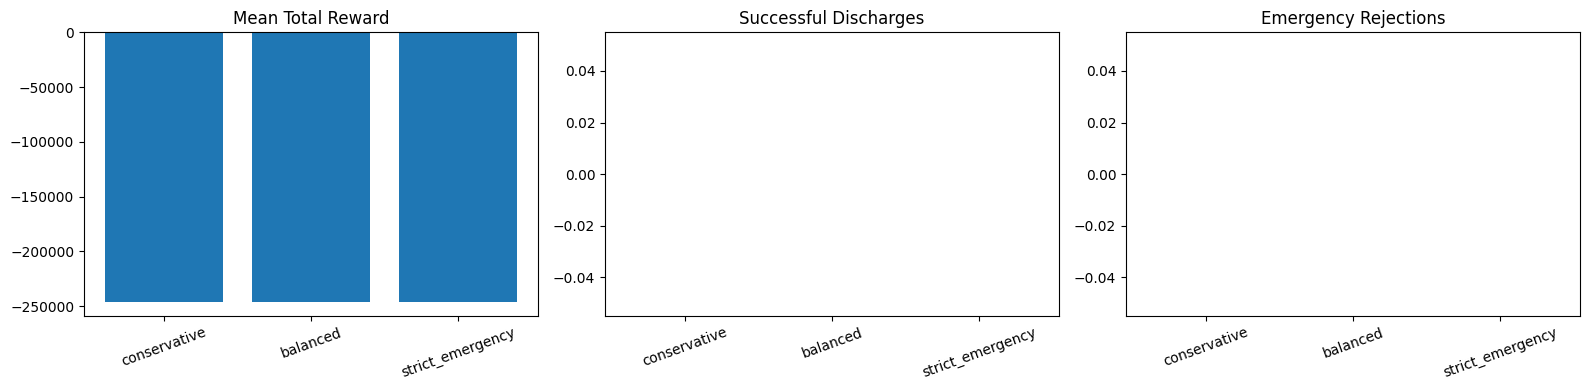

In [24]:
def plot_reward_sensitivity_summary(sensitivity_summary_df):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].bar(sensitivity_summary_df["setting"], sensitivity_summary_df["mean_total_reward"])
    axes[0].set_title("Mean Total Reward")
    axes[0].tick_params(axis="x", rotation=20)

    axes[1].bar(sensitivity_summary_df["setting"], sensitivity_summary_df["mean_successful_discharges"])
    axes[1].set_title("Successful Discharges")
    axes[1].tick_params(axis="x", rotation=20)

    emergency_metric = "mean_emergency_rejections"
    axes[2].bar(sensitivity_summary_df["setting"], sensitivity_summary_df[emergency_metric])
    axes[2].set_title("Emergency Rejections")
    axes[2].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()


plot_reward_sensitivity_summary(sensitivity_summary_df)


## Plot Best-Setting Action Frequencies
This diagnostic checks whether the best pilot policy still overuses no-op or delay actions.

Most common PPO actions:
  11: discharge_patient -> 3897 selections
  2: move_to_assessment -> 941 selections
  6: request_imaging -> 162 selections
  1: register_patient -> 0 selections
  3: send_to_minor -> 0 selections


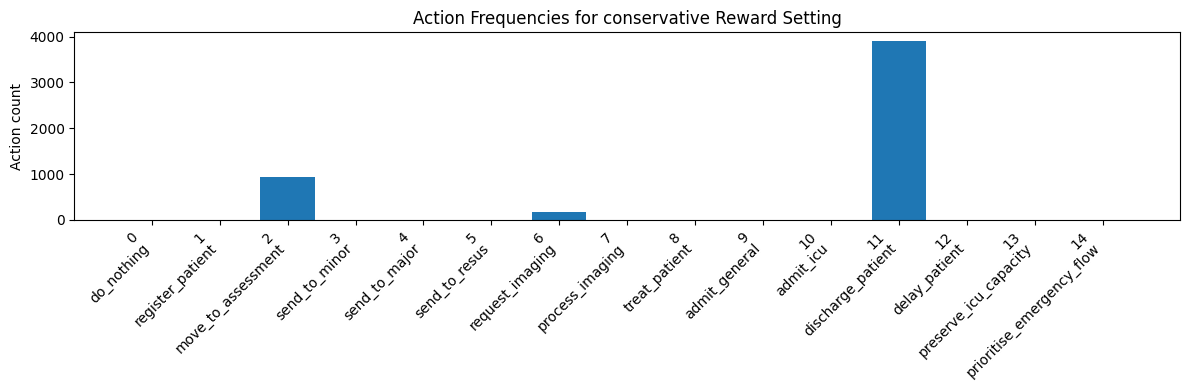

In [25]:
best_reward_setting = select_best_reward_setting(sensitivity_summary_df)
best_action_counts_df = sensitivity_action_counts[best_reward_setting]
print_most_common_actions(best_action_counts_df)
plot_action_frequencies(
    best_action_counts_df,
    title=f"Action Frequencies for {best_reward_setting} Reward Setting",
)


## Results Summary Function
This compares PPO and random-policy means and standard deviations.

In [26]:
def summarise_results(ppo_results, random_results):
    metrics = [
        "total_reward",
        "emergency_delays",
        "emergency_rejections",
        "unsafe_discharges",
        "icu_admissions",
        "general_admissions",
        "successful_discharges",
        "queue_congestion_events",
        "invalid_actions",
        "invalid_action_rate"
    ]

    summary_rows = []

    for metric in metrics:
        if metric not in ppo_results.columns or metric not in random_results.columns:
            continue

        summary_rows.append({
            "metric": metric,
            "ppo_mean": ppo_results[metric].mean(),
            "random_mean": random_results[metric].mean(),
            "ppo_std": ppo_results[metric].std(),
            "random_std": random_results[metric].std()
        })

    return pd.DataFrame(summary_rows)


## Plotting Function
This plots one selected metric for PPO and the random baseline.

In [27]:
def plot_metric_comparison(summary_df, metric):
    row = summary_df[summary_df["metric"] == metric].iloc[0]

    labels = ["PPO", "Random"]
    values = [row["ppo_mean"], row["random_mean"]]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, values)
    plt.title(f"PPO vs Random Policy: {metric}")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

## Save Results Function
This saves the PPO model and the CSV evaluation outputs.

In [28]:
def save_results(model, ppo_results, random_results, summary_df):
    model.save("ppo_hospital_flow_model")

    ppo_results.to_csv("ppo_evaluation_results.csv", index=False)
    random_results.to_csv("random_policy_results.csv", index=False)
    summary_df.to_csv("ppo_vs_random_summary.csv", index=False)

    print("Saved PPO model: ppo_hospital_flow_model.zip")
    print("Saved PPO results: ppo_evaluation_results.csv")
    print("Saved random baseline results: random_policy_results.csv")
    print("Saved comparison summary: ppo_vs_random_summary.csv")

## Train PPO Agent
This trains the final PPO model with reward shaping and action guardrails, defaulting to balanced if pilots were not run.


In [29]:
selected_reward_config = get_selected_reward_config(globals().get("sensitivity_summary_df"))
model = train_ppo_agent(
    total_timesteps=750000,
    seed=42,
    reward_config=selected_reward_config,
    use_reward_shaping=True,
    use_action_guardrail=True,
)


Selected reward setting: conservative
Using cuda device
Wrapping the env in a DummyVecEnv.


c:\Users\ybenj\anaconda3\envs\sb3-ppo\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 500       |
|    ep_rew_mean     | -2.26e+05 |
| time/              |           |
|    fps             | 534       |
|    iterations      | 1         |
|    time_elapsed    | 0         |
|    total_timesteps | 512       |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 500          |
|    ep_rew_mean          | -2.16e+05    |
| time/                   |              |
|    fps                  | 429          |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 1024         |
| train/                  |              |
|    approx_kl            | 3.316556e-06 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.71        |
|    explained_variance   | 7.48e-05     |
|    

## Gymnasium Compatibility Helpers
These helpers allow the evaluation loops to work with both Gymnasium and older Gym reset/step return formats.


In [30]:
def reset_env_compat(env, seed=None):
    if seed is None:
        result = env.reset()
    else:
        result = env.reset(seed=seed)

    if isinstance(result, tuple) and len(result) == 2:
        return result

    return result, {}


def step_env_compat(env, action):
    result = env.step(action)

    if len(result) == 5:
        obs, reward, terminated, truncated, info = result
        return obs, reward, terminated, truncated, info

    obs, reward, done, info = result
    return obs, reward, done, False, info


## Manual PPO Learning-Curve Evaluation
This evaluates the trained PPO policy for 1500 episodes and stores reward, emergency rejections, and mean ICU utilisation.


In [31]:
def evaluate_ppo_learning_curves(model, n_episodes=1500, seed=42):
    env = HospitalPPOEnv()
    episode_rewards = []
    emergency_rejections = []
    mean_icu_utilisations = []

    for episode in range(n_episodes):
        obs, info = reset_env_compat(env, seed=seed + episode)
        done = False
        total_reward = 0.0
        rejection_count = 0
        icu_values = []

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            action = int(np.asarray(action).item())
            obs, reward, terminated, truncated, info = step_env_compat(env, action)
            done = terminated or truncated

            total_reward += float(reward)
            rejection_count += int(info.get("emergency_rejection", 0))
            icu_values.append(float(info.get("icu_utilisation", 0.0)))

        episode_rewards.append(total_reward)
        emergency_rejections.append(rejection_count)
        mean_icu_utilisations.append(float(np.mean(icu_values)) if icu_values else 0.0)

    return pd.DataFrame({
        "episode": np.arange(n_episodes),
        "episode_reward": episode_rewards,
        "emergency_rejections": emergency_rejections,
        "icu_utilisation": mean_icu_utilisations,
    })


## Random Baseline Learning-Curve Evaluation
This evaluates random actions with the same 1500-episode metrics used for PPO.


In [32]:
def evaluate_random_learning_curves(n_episodes=1500, seed=42):
    env = HospitalPPOEnv()
    episode_rewards = []
    emergency_rejections = []
    mean_icu_utilisations = []

    for episode in range(n_episodes):
        obs, info = reset_env_compat(env, seed=seed + episode)
        done = False
        total_reward = 0.0
        rejection_count = 0
        icu_values = []

        while not done:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = step_env_compat(env, action)
            done = terminated or truncated

            total_reward += float(reward)
            rejection_count += int(info.get("emergency_rejection", 0))
            icu_values.append(float(info.get("icu_utilisation", 0.0)))

        episode_rewards.append(total_reward)
        emergency_rejections.append(rejection_count)
        mean_icu_utilisations.append(float(np.mean(icu_values)) if icu_values else 0.0)

    return pd.DataFrame({
        "episode": np.arange(n_episodes),
        "episode_reward": episode_rewards,
        "emergency_rejections": emergency_rejections,
        "icu_utilisation": mean_icu_utilisations,
    })


## Run Learning-Curve Evaluations
These cells create full episode-by-episode PPO and random baseline result tables.


In [33]:
ppo_curve_results = evaluate_ppo_learning_curves(model, n_episodes=1500, seed=42)
ppo_curve_results.head()


,episode,episode_reward,emergency_rejections,icu_utilisation
0,0,-250506.0,0,0.0
1,1,-268690.0,0,0.0
2,2,-273928.0,0,0.0
3,3,-231391.0,0,0.0
4,4,-269249.0,0,0.0


## Run Random Learning-Curve Baseline
The random baseline uses the same metric columns for direct comparison.


In [34]:
random_curve_results = evaluate_random_learning_curves(n_episodes=1500, seed=42)
random_curve_results.head()


,episode,episode_reward,emergency_rejections,icu_utilisation
0,0,-179442.2,38,0.000333
1,1,-226319.9,32,0.000000
2,2,-199265.4,39,0.000000
3,3,-169328.4,30,0.000000
4,4,-187896.1,26,0.000000


## PPO Episode Reward Curve
This line graph shows PPO total episode reward over all evaluation episodes.


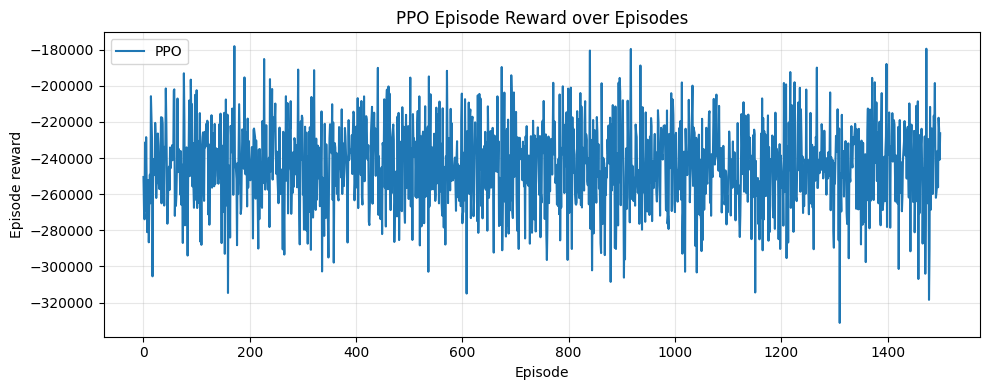

In [35]:
plt.figure(figsize=(10, 4))
plt.plot(ppo_curve_results["episode"], ppo_curve_results["episode_reward"], label="PPO")
plt.xlabel("Episode")
plt.ylabel("Episode reward")
plt.title("PPO Episode Reward over Episodes")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## PPO versus Random Reward Curve
This line graph compares PPO episode reward with the random policy baseline.


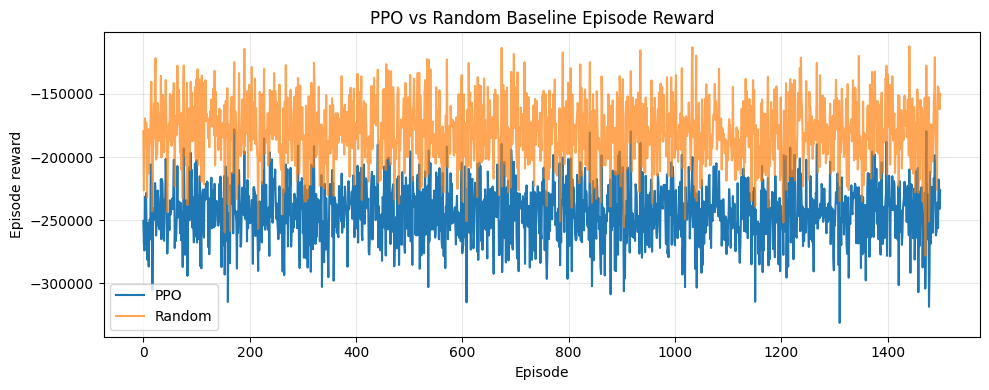

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(ppo_curve_results["episode"], ppo_curve_results["episode_reward"], label="PPO")
plt.plot(random_curve_results["episode"], random_curve_results["episode_reward"], label="Random", alpha=0.7)
plt.xlabel("Episode")
plt.ylabel("Episode reward")
plt.title("PPO vs Random Baseline Episode Reward")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## PPO Emergency Rejection Curve
This line graph shows emergency rejections per PPO evaluation episode.


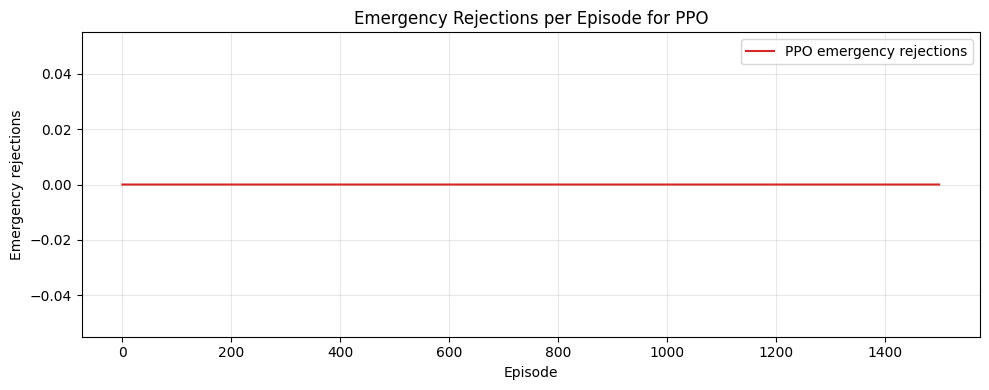

In [37]:
plt.figure(figsize=(10, 4))
plt.plot(ppo_curve_results["episode"], ppo_curve_results["emergency_rejections"], label="PPO emergency rejections", color="tab:red")
plt.xlabel("Episode")
plt.ylabel("Emergency rejections")
plt.title("Emergency Rejections per Episode for PPO")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## PPO ICU Utilisation Curve
This line graph shows mean ICU utilisation rate per PPO evaluation episode.


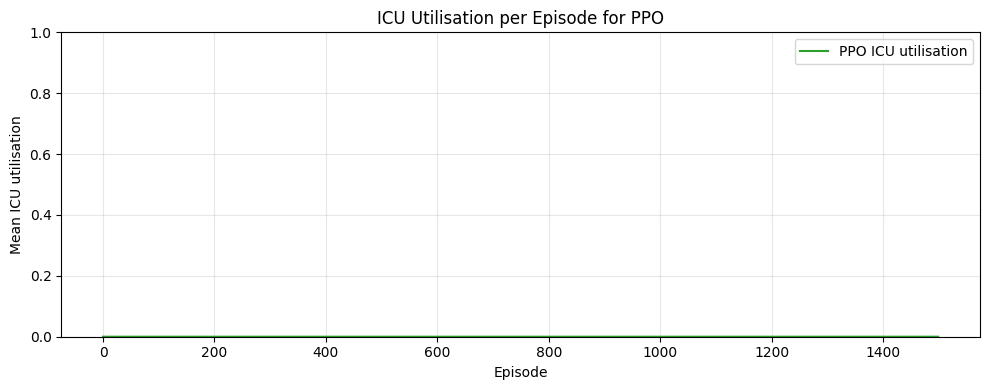

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(ppo_curve_results["episode"], ppo_curve_results["icu_utilisation"], label="PPO ICU utilisation", color="tab:green")
plt.xlabel("Episode")
plt.ylabel("Mean ICU utilisation")
plt.title("ICU Utilisation per Episode for PPO")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Three-Panel PPO Metrics Plot
This mirrors the coursework learning-curve style: reward, emergency rejections, and ICU utilisation.


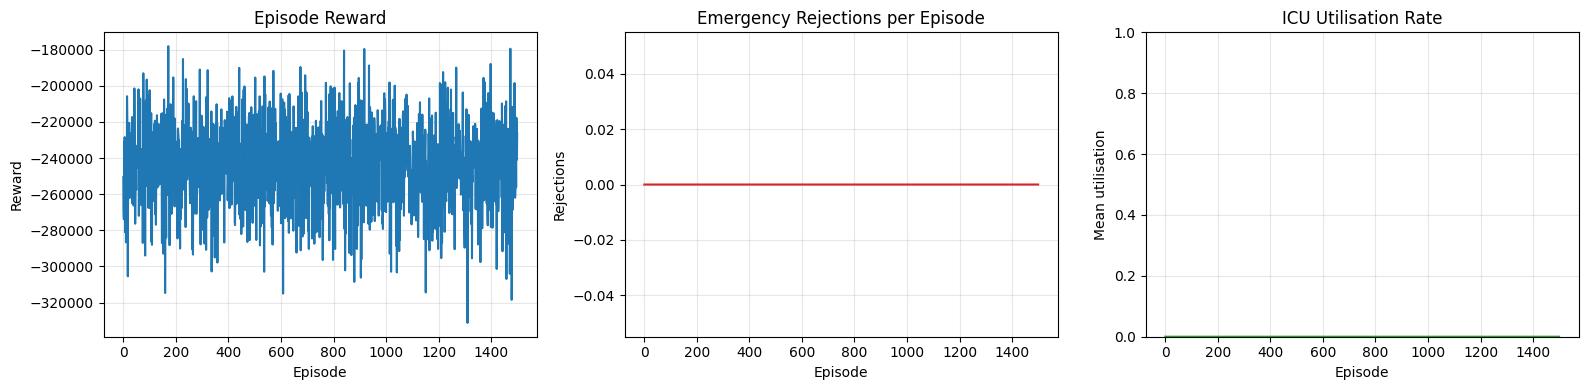

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(ppo_curve_results["episode"], ppo_curve_results["episode_reward"])
axes[0].set_title("Episode Reward")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].grid(alpha=0.3)

axes[1].plot(ppo_curve_results["episode"], ppo_curve_results["emergency_rejections"], color="tab:red")
axes[1].set_title("Emergency Rejections per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Rejections")
axes[1].grid(alpha=0.3)

axes[2].plot(ppo_curve_results["episode"], ppo_curve_results["icu_utilisation"], color="tab:green")
axes[2].set_title("ICU Utilisation Rate")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Mean utilisation")
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## PPO Policy-Action Heatmap Helper
PPO has no Q-table, so this heatmap shows the action selected by the trained policy over bed-capacity states.


In [40]:
def build_policy_action_grid(model, patient_type, env=None):
    env = env or HospitalPPOEnv()
    action_grid = np.zeros((env.icu_max + 1, env.general_max + 1), dtype=int)

    for icu_free in range(env.icu_max + 1):
        for general_free in range(env.general_max + 1):
            obs = np.asarray([
                0,
                1,
                env.resus_max,
                env.major_max,
                env.minor_max,
                general_free,
                icu_free,
                patient_type,
                2,
                0,
                STAFF_SCHEDULE["day"]["nurses"],
                STAFF_SCHEDULE["day"]["doctors"],
                STAFF_SCHEDULE["day"]["physicians"],
                STAFF_SCHEDULE["day"]["radiologists"],
                STAFF_SCHEDULE["day"]["receptionists"],
                STAFF_SCHEDULE["day"]["administrators"],
                STAFF_SCHEDULE["day"]["paramedics"],
                SHIFT_ENCODING["day"],
            ], dtype=np.float32)
            action, _ = model.predict(obs, deterministic=True)
            action_grid[icu_free, general_free] = int(np.asarray(action).item())

    return action_grid


def plot_policy_action_heatmap(model, patient_type):
    env = HospitalPPOEnv()
    grid = build_policy_action_grid(model, patient_type, env=env)

    plt.figure(figsize=(12, 4))
    im = plt.imshow(grid, origin="lower", aspect="auto", cmap="tab20")
    plt.colorbar(im, label="Selected PPO action")
    plt.xlabel("General beds free")
    plt.ylabel("ICU beds free")
    plt.title(f"PPO Policy-Action Heatmap: patient type {patient_type} ({PATIENT_TYPES[patient_type]})")
    plt.xticks(range(env.general_max + 1))
    plt.yticks(range(env.icu_max + 1))
    plt.tight_layout()
    plt.show()


## PPO Policy-Action Heatmaps
These plots sweep ICU beds, general beds, and patient type to visualise the PPO policy action.


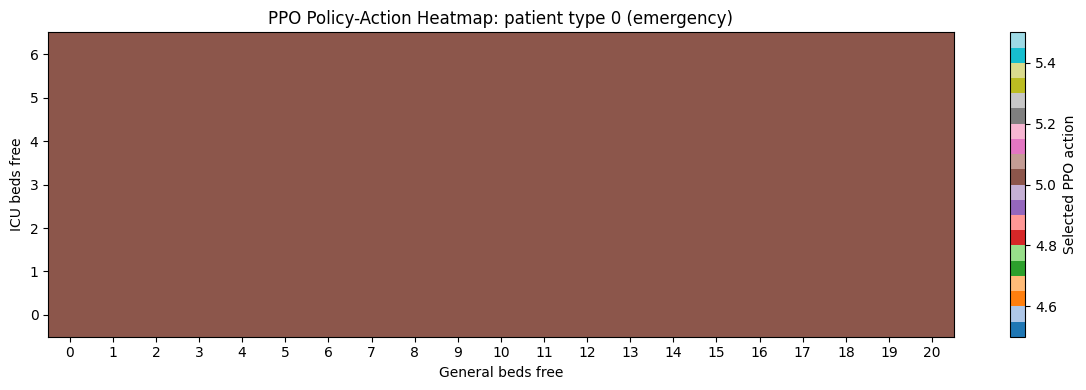

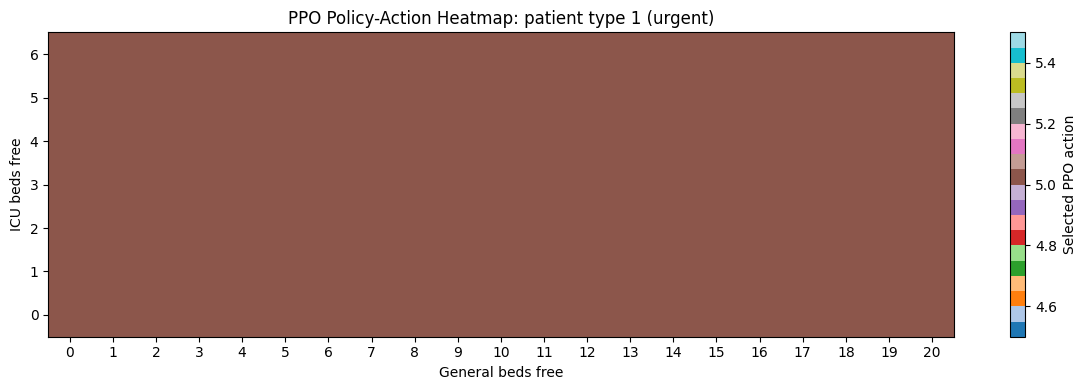

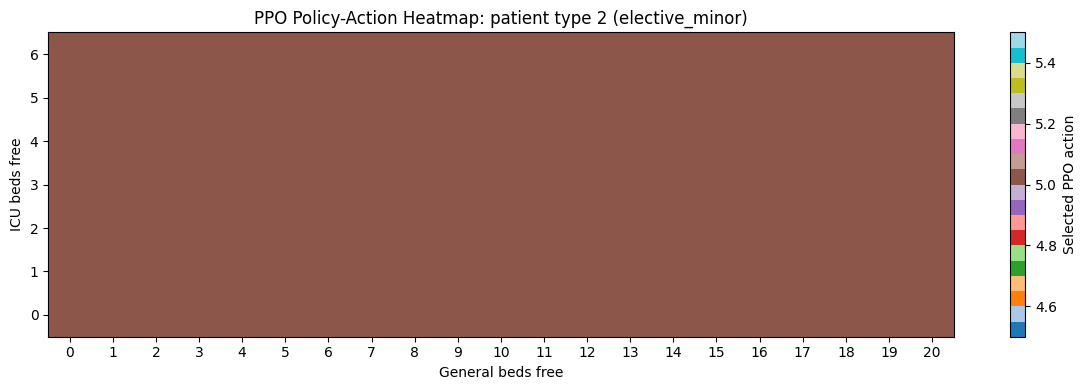

In [41]:
for patient_type in [0, 1, 2]:
    plot_policy_action_heatmap(model, patient_type)


## Evaluate PPO Agent
This evaluates the trained PPO policy for 20 episodes.

In [42]:
ppo_results, ppo_action_counts_df = evaluate_agent(
    model,
    n_episodes=20,
    return_action_counts=True,
)
ppo_results.head()


,episode,total_reward,steps,emergency_delays,emergency_rejections,unsafe_discharges,icu_admissions,general_admissions,successful_discharges,queue_congestion_events,invalid_actions,guarded_actions,invalid_action_rate,most_common_action
0,0,-256681.0,500,0,0,0,0,0,0,0,500,0,1.0,2: move_to_assessment
1,1,-238445.0,500,0,0,0,0,0,0,0,500,0,1.0,2: move_to_assessment
2,2,-211839.0,500,0,0,0,0,0,0,0,500,0,1.0,2: move_to_assessment
3,3,-231511.0,500,0,0,0,0,0,0,0,500,0,1.0,2: move_to_assessment
4,4,-255283.0,500,0,0,0,0,0,0,0,500,0,1.0,2: move_to_assessment


## PPO Action Frequency Diagnostics
A useful policy should not rely mainly on no-op, delay, or other non-progressing actions.

Most common PPO actions:
  2: move_to_assessment -> 9560 selections
  5: send_to_resus -> 440 selections
  0: do_nothing -> 0 selections
  1: register_patient -> 0 selections
  3: send_to_minor -> 0 selections


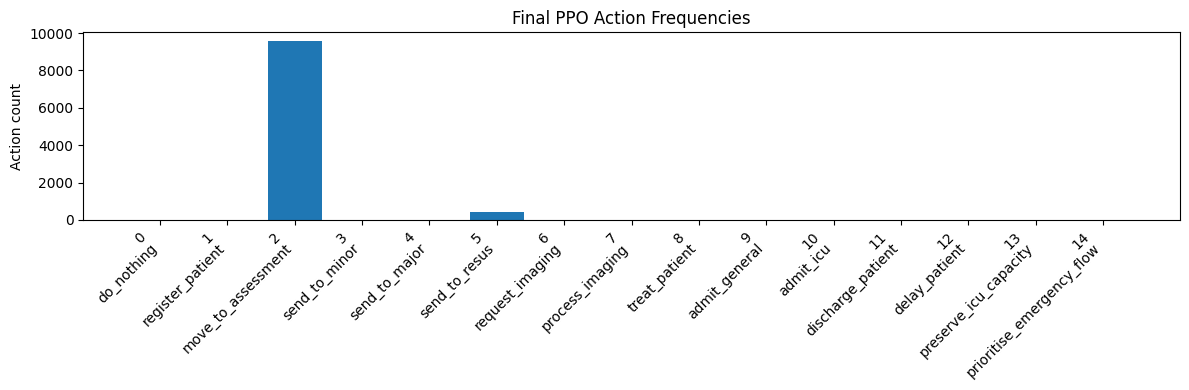

In [43]:
print_most_common_actions(ppo_action_counts_df)
plot_action_frequencies(ppo_action_counts_df, title="Final PPO Action Frequencies")


## PPO Invalid-Action Diagnostics
This checks whether PPO is still choosing actions that are impossible for the current hospital stage.

invalid_actions             500.00
guarded_actions               0.00
invalid_action_rate           1.00
successful_discharges         0.00
general_admissions            0.00
icu_admissions                0.00
total_reward            -242696.55
dtype: float64


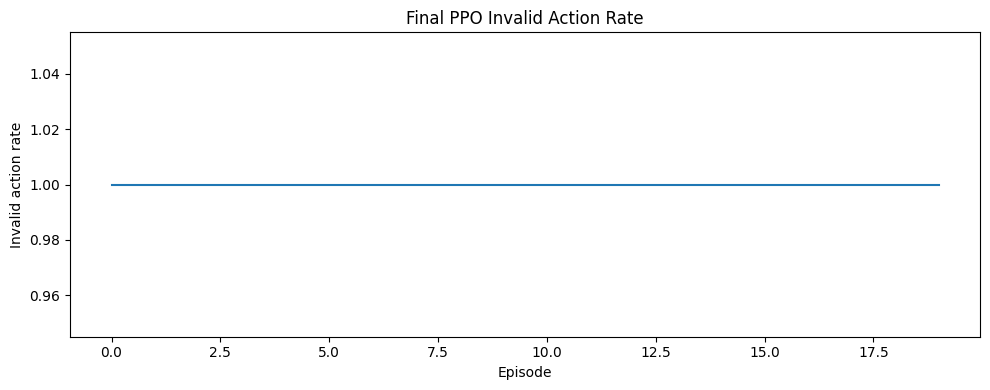

In [44]:
print(summarise_action_validity(ppo_results))
plot_invalid_action_rates(ppo_results, title="Final PPO Invalid Action Rate")


## Evaluate Random Baseline
This evaluates random actions for 20 episodes using the same environment.

In [45]:
random_results = evaluate_random_policy(n_episodes=20, seed=42)
random_results.head()

,episode,total_reward,steps,emergency_delays,emergency_rejections,unsafe_discharges,icu_admissions,general_admissions,successful_discharges,queue_congestion_events,invalid_actions,invalid_action_rate
0,0,-191461.1,500,31,31,0,1,1,7,0,240,0.480
1,1,-176538.3,500,39,39,0,0,0,1,0,252,0.504
2,2,-211558.5,500,39,38,0,0,0,2,0,275,0.550
3,3,-140473.8,500,32,32,0,0,0,1,0,250,0.500
4,4,-193496.4,500,32,32,0,0,0,4,0,280,0.560


## Compare PPO vs Random Policy
This summary table compares PPO against the random baseline across all metrics.

In [46]:
summary_df = summarise_results(ppo_results, random_results)
summary_df

,metric,ppo_mean,random_mean,ppo_std,random_std
0,total_reward,-242696.55,-182307.8450,17410.521524,27306.446096
1,emergency_delays,0.00,32.5500,0.000000,4.762518
2,emergency_rejections,0.00,32.3000,0.000000,4.758372
3,unsafe_discharges,0.00,0.0000,0.000000,0.000000
4,icu_admissions,0.00,0.1000,0.000000,0.307794
5,general_admissions,0.00,0.4500,0.000000,0.686333
6,successful_discharges,0.00,2.6500,0.000000,1.496487
7,queue_congestion_events,0.00,6.3000,0.000000,18.116872
8,invalid_actions,500.00,264.5500,0.000000,21.813745
9,invalid_action_rate,1.00,0.5291,0.000000,0.043627


## Plot Total Reward
This plot compares cumulative reward for PPO and random actions.

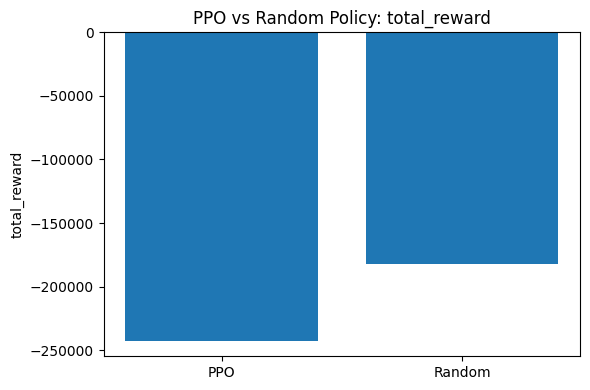

In [47]:
plot_metric_comparison(summary_df, "total_reward")

## Plot Emergency Delays
This plot compares emergency delay events for PPO and random actions.

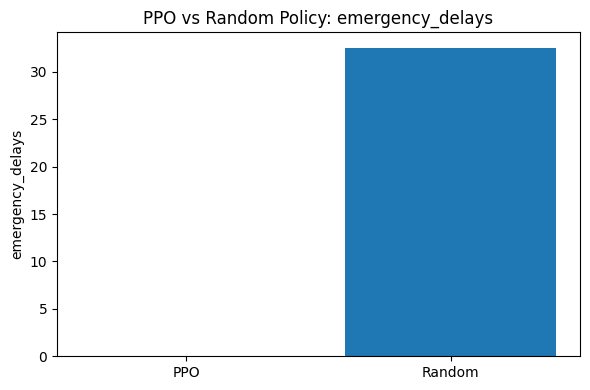

In [48]:
plot_metric_comparison(summary_df, "emergency_delays")

## Plot Successful Discharges
This plot compares successful discharges for PPO and random actions.

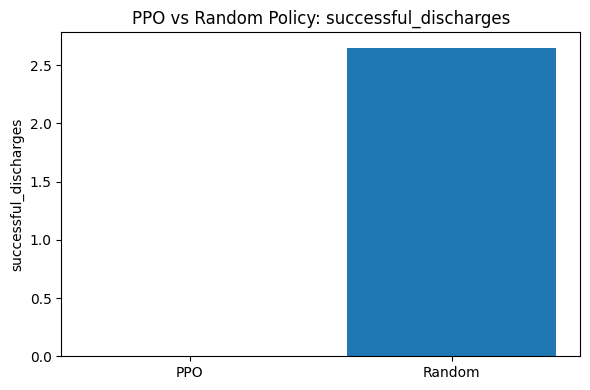

In [49]:
plot_metric_comparison(summary_df, "successful_discharges")

## Plot Unsafe Discharges
This plot compares unsafe discharges for PPO and random actions.

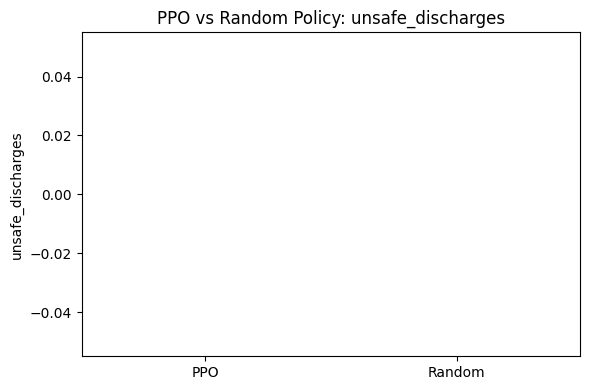

In [50]:
plot_metric_comparison(summary_df, "unsafe_discharges")

## Plot Queue Congestion
This plot compares queue congestion events for PPO and random actions.

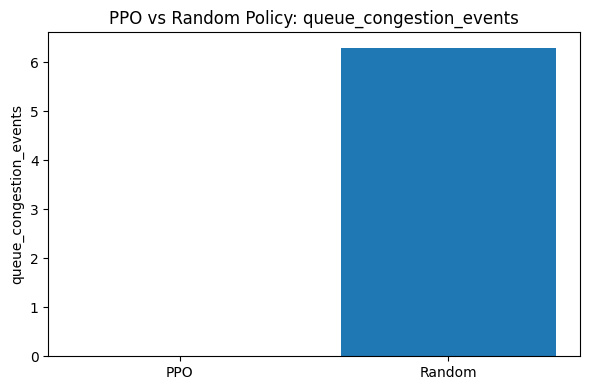

In [51]:
plot_metric_comparison(summary_df, "queue_congestion_events")

## Save Model and CSV Outputs
This saves the trained model, detailed evaluations, and comparison summary.

In [52]:
save_results(model, ppo_results, random_results, summary_df)

Saved PPO model: ppo_hospital_flow_model.zip
Saved PPO results: ppo_evaluation_results.csv
Saved random baseline results: random_policy_results.csv
Saved comparison summary: ppo_vs_random_summary.csv


## Final Summary
After running, PPO has been trained on the operational hospital-flow environment and compared against a random policy baseline using cumulative reward, emergency delays, unsafe discharges, admissions, successful discharges, and queue congestion.

## Reward-Shaping Interpretation
A useful PPO policy should beat random reward while showing non-zero admissions/discharges and controlled emergency failures.

## Targeted Fix: Action Validity
The targeted fix in this iteration addresses action validity, because the saved PPO output repeatedly selected `move_to_assessment` without throughput.

## Final Printed Summary
This cell prints completion status and the actual summary table produced by the run.

In [53]:
print("PPO training and evaluation complete.")
print(summary_df)

PPO training and evaluation complete.
                    metric   ppo_mean  random_mean       ppo_std    random_std
0             total_reward -242696.55 -182307.8450  17410.521524  27306.446096
1         emergency_delays       0.00      32.5500      0.000000      4.762518
2     emergency_rejections       0.00      32.3000      0.000000      4.758372
3        unsafe_discharges       0.00       0.0000      0.000000      0.000000
4           icu_admissions       0.00       0.1000      0.000000      0.307794
5       general_admissions       0.00       0.4500      0.000000      0.686333
6    successful_discharges       0.00       2.6500      0.000000      1.496487
7  queue_congestion_events       0.00       6.3000      0.000000     18.116872
8          invalid_actions     500.00     264.5500      0.000000     21.813745
9      invalid_action_rate       1.00       0.5291      0.000000      0.043627
